# Tabular regression with `LanguageModelRegressor`

The target is a number, so the model defines a distribution over the *text* of that number. The
regressor reads off a point estimate in one of two ways:

- **Sampling** (default): generate the value `n_samples` times and average the draws.
- **Scoring** (`discretization=DiscretizationConfig(...)`): rank a fixed set of candidate values
  by likelihood and collapse that distribution to a number. The estimate never leaves the observed
  range.

Both are predict-time choices on the same fitted weights.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

from sklm import DiscretizationConfig, GenerationConfig, LanguageModelRegressor

sns.set_theme(style="whitegrid", context="notebook")
SEED = 42

## Data

Auto MPG: seven attributes of late-1970s cars (`origin` is a string) and the fuel efficiency in
miles per gallon to predict. `seaborn` fetches the table once and caches it.

In [6]:
mpg = sns.load_dataset("mpg").dropna()
features = [
    "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin",
]
X = mpg[features].round(1)
y = mpg["mpg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
260,6,225.0,110.0,3620,18.7,78,usa
184,4,140.0,92.0,2572,14.9,76,usa
174,6,171.0,97.0,2984,14.5,75,usa
64,8,318.0,150.0,4135,13.5,72,usa
344,4,86.0,64.0,1875,16.4,81,usa


## Fine-tuning

Everything on defaults: `target_loss_weight=1.0` supervises only the target tokens, and training
runs until validation loss stops improving.

In [3]:
reg = LanguageModelRegressor(
    backend="mlx",
    model="mlx-community/distilgpt2",
    random_state=SEED,
).fit(X_train, y_train)

## Sampling vs. scoring

The scoring call cuts the observed `mpg` range into equal-width bins (`strategy="uniform"`, 20% as
many as there are distinct values), ranks the bin representatives by likelihood and sharpens the
distribution (`sharpness=4.0` raises the probabilities to that power) before taking the mean;
`n_samples=30` scores each row under 30 column orders and pools them.

MAE and RMSE are in miles per gallon; $R^2$ is 1 for a perfect fit, 0 for always predicting the
training mean, negative below that. The mean baseline is printed for reference.

In [4]:
pred_sampled = reg.predict(X_test, generation=GenerationConfig(n_samples=20))
pred_scored = reg.predict(
    X_test,
    discretization=DiscretizationConfig(bins=0.2, sharpness=4.0, strategy="uniform"),
    generation=GenerationConfig(n_samples=30),
)
baseline = np.full(len(y_test), y_train.mean())

for name, pred in [("sampled", pred_sampled), ("scored", pred_scored), ("mean", baseline)]:
    print(
        f"{name:8} R2: {r2_score(y_test, pred):6.3f}"
        f"   MAE: {mean_absolute_error(y_test, pred):5.2f}"
        f"   RMSE: {root_mean_squared_error(y_test, pred):5.2f}"
    )

HTML(value='')

HTML(value='')

sampled  R2:  0.835   MAE:  2.18   RMSE:  2.90
scored   R2:  0.840   MAE:  2.17   RMSE:  2.86
mean     R2: -0.011   MAE:  5.88   RMSE:  7.18


## Predicted vs. true

Points on the dashed line $\hat{y} = y$ are perfect predictions.

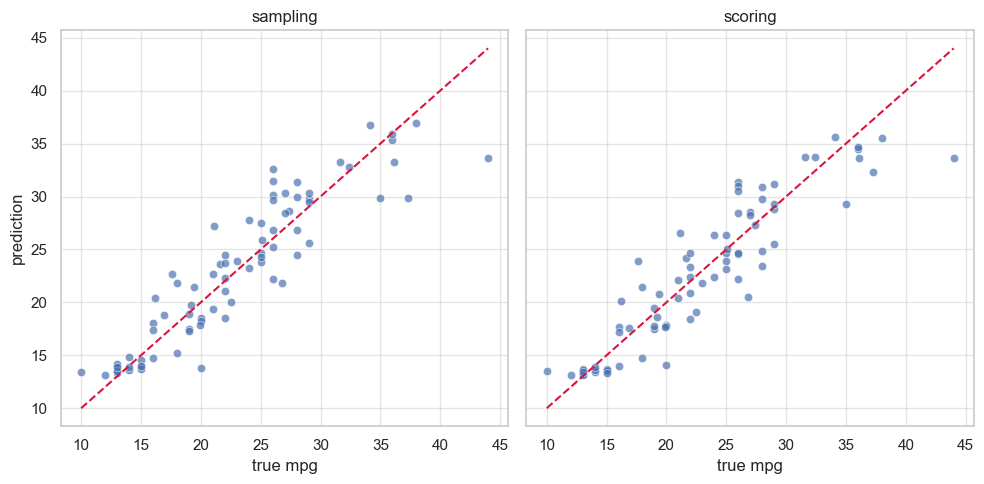

In [5]:
lo, hi = float(y_test.min()), float(y_test.max())
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for ax, (name, pred) in zip(axes, [("sampling", pred_sampled), ("scoring", pred_scored)]):
    sns.scatterplot(x=y_test, y=pred, ax=ax, alpha=0.7)
    ax.plot([lo, hi], [lo, hi], color="crimson", linestyle="--")
    ax.set_xlabel("true mpg")
    ax.set_ylabel("prediction")
    ax.set_title(name)
plt.tight_layout()
plt.show()